# Van der Pol Carleman simulations

## Imports and parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import expm_multiply

mu = 0.5
final_time = 0.1
trajectory_time_points = 1001
map_time_points = 301
grid_points = 101
chunk_size = 1024

trajectory_initial = np.array([2.0, -1.0])
trajectory_orders = [1, 5, 10, 20]
map_orders = [1, 10, 20]

## Model and Simulation Functions

The Van der Pol oscillator is

$$
\ddot{x}-\mu(1-x^2)\dot{x}+x=0.
$$

With $x_1=x$ and $x_2=\dot{x}$,

$$
\dot{x}_1=x_2,
\qquad
\dot{x}_2=-x_1+\mu(1-x_1^2)x_2.
$$

For degree $k$, the lifted block is ordered as

$$
z_k=
\begin{bmatrix}
x_1^k & x_1^{k-1}x_2 & \cdots & x_2^k
\end{bmatrix}^{T}.
$$

For the row corresponding to $x_1^{k-b}x_2^b$, the nonzero entries are

$$
(A_{k,k})_{b,b+1}=k-b,
\qquad
(A_{k,k})_{b,b-1}=-b,
\qquad
(A_{k,k})_{b,b}=\mu b,
$$

and

$$
(A_{k,k+2})_{b,b}=-\mu b.
$$

The finite-section dimension is

$$
\sum_{k=1}^{N}(k+1)=\frac{N(N+3)}{2}.
$$

For Figure 4.3, the displayed error is

$$
E(x_0,v_0,N,T^*)=
\log_{10}\!\left(
\min\left\{
\max\left\{
\sup_{0\leq t\leq T^*}
\left\|y_{1,N}(t)-
\begin{bmatrix}
x(t)\\
\dot{x}(t)
\end{bmatrix}
\right\|_{\infty},
10^{-15}
\right\},
10^5
\right\}
\right).
$$

In [2]:
def vdp_rhs(state):
    x1 = state[..., 0]
    x2 = state[..., 1]

    return np.stack(
        (
            x2,
            -x1 + mu * (1.0 - x1**2) * x2,
        ),
        axis=-1,
    )


def vdp_rhs_flat(_, flat_state):
    return vdp_rhs(flat_state.reshape(-1, 2)).ravel()


def block_offsets(order):
    offsets = {}
    dimension = 0

    for degree in range(1, order + 1):
        offsets[degree] = dimension
        dimension += degree + 1

    return offsets, dimension


def carleman_matrix(order):
    offsets, dimension = block_offsets(order)
    rows = []
    columns = []
    values = []

    for degree in range(1, order + 1):
        offset = offsets[degree]

        for b in range(degree + 1):
            if b < degree:
                rows.append(offset + b)
                columns.append(offset + b + 1)
                values.append(degree - b)

            if b > 0:
                rows.extend([offset + b, offset + b])
                columns.extend([offset + b - 1, offset + b])
                values.extend([-b, mu * b])

            if degree + 2 <= order and b > 0:
                rows.append(offset + b)
                columns.append(offsets[degree + 2] + b)
                values.append(-mu * b)

    return csr_matrix(
        (values, (rows, columns)),
        shape=(dimension, dimension),
        dtype=float,
    )


def lift_state(state, order):
    x1, x2 = state
    lifted = []

    for degree in range(1, order + 1):
        for b in range(degree + 1):
            lifted.append(x1 ** (degree - b) * x2**b)

    return np.asarray(lifted, dtype=float)


def lift_initial_conditions(x1, x2, order):
    lifted = []

    for degree in range(1, order + 1):
        for b in range(degree + 1):
            lifted.append(x1 ** (degree - b) * x2**b)

    return np.asarray(lifted)


def nonlinear_solution(times, initial):
    return solve_ivp(
        lambda _, state: vdp_rhs(state),
        (times[0], times[-1]),
        initial,
        t_eval=times,
        rtol=1e-10,
        atol=1e-12,
        method="DOP853",
    ).y.T


def carleman_solution(times, initial, order):
    matrix = carleman_matrix(order)
    lifted_initial = lift_state(initial, order)

    lifted = expm_multiply(
        matrix,
        lifted_initial,
        start=float(times[0]),
        stop=float(times[-1]),
        num=times.size,
        endpoint=True,
        traceA=float(matrix.diagonal().sum()),
    )
    return lifted[:, :2]


def first_block_coefficients(matrix, times):
    basis = np.zeros((matrix.shape[0], 2))
    basis[0, 0] = 1.0
    basis[1, 1] = 1.0

    return expm_multiply(
        matrix.T,
        basis,
        start=float(times[0]),
        stop=float(times[-1]),
        num=times.size,
        endpoint=True,
        traceA=float(matrix.diagonal().sum()),
    )


def nonlinear_truth(initial_states, times):
    solution = solve_ivp(
        vdp_rhs_flat,
        (times[0], times[-1]),
        initial_states.ravel(),
        t_eval=times,
        rtol=1e-10,
        atol=1e-12,
        method="DOP853",
    )
    return solution.y.T.reshape(times.size, initial_states.shape[0], 2)


def carleman_approximation(coefficients, x1, x2, order):
    lifted = lift_initial_conditions(x1, x2, order)
    return np.einsum(
        "tdo,dm->tmo",
        coefficients,
        lifted,
        optimize=True,
    )


def trajectory(initial, duration, points=1800):
    times = np.linspace(0.0, duration, points)
    return nonlinear_solution(times, np.asarray(initial, dtype=float))


def limit_cycle():
    def crossing(_, state):
        return state[0]

    crossing.direction = 1
    crossing.terminal = False

    solution = solve_ivp(
        lambda _, state: vdp_rhs(state),
        (0.0, 200.0),
        [2.0, 0.0],
        events=crossing,
        dense_output=True,
        rtol=1e-11,
        atol=1e-13,
        max_step=0.05,
        method="DOP853",
    )

    crossings = solution.t_events[0]
    cycle_times = np.linspace(crossings[-2], crossings[-1], 1500)
    return solution.sol(cycle_times).T, crossings[-1] - crossings[-2]

## Simulation

### Trajectory data

In [3]:
trajectory_times = np.linspace(0.0, final_time, trajectory_time_points)
trajectory_exact = nonlinear_solution(trajectory_times, trajectory_initial)
trajectory_approximations = {
    order: carleman_solution(trajectory_times, trajectory_initial, order)
    for order in trajectory_orders
}
trajectory_errors = {
    order: np.linalg.norm(
        trajectory_approximations[order] - trajectory_exact,
        ord=np.inf,
        axis=1,
    )
    for order in trajectory_orders
}

### Vector-field and limit-cycle data

In [4]:
field_grid = np.linspace(-6.0, 6.0, 41)
X1, X2 = np.meshgrid(field_grid, field_grid)
U = X2
V = -X1 + mu * (1.0 - X1**2) * X2

outer_trajectory = trajectory([4.0, 4.0], 10.0, 2500)
inner_trajectory = trajectory([0.1, 0.0], 18.0, 2500)
cycle, cycle_period = limit_cycle()

### Figure 4.3 data

In [5]:
grid = np.linspace(-6.0, 6.0, grid_points)
X0, V0 = np.meshgrid(grid, grid)
initial_states = np.column_stack((X0.ravel(), V0.ravel()))
map_times = np.linspace(0.0, final_time, map_time_points)

matrices = {order: carleman_matrix(order) for order in map_orders}
coefficients = {
    order: first_block_coefficients(matrices[order], map_times)
    for order in map_orders
}
flat_errors = {
    order: np.empty(initial_states.shape[0], dtype=float)
    for order in map_orders
}

for start in range(0, initial_states.shape[0], chunk_size):
    stop = min(start + chunk_size, initial_states.shape[0])
    initial_chunk = initial_states[start:stop]
    truth = nonlinear_truth(initial_chunk, map_times)

    for order in map_orders:
        approximation = carleman_approximation(
            coefficients[order],
            initial_chunk[:, 0],
            initial_chunk[:, 1],
            order,
        )
        flat_errors[order][start:stop] = np.max(
            np.linalg.norm(approximation - truth, ord=np.inf, axis=2),
            axis=0,
        )

error_maps = {
    order: flat_errors[order].reshape(grid_points, grid_points)
    for order in map_orders
}

## Results

### Trajectory comparison

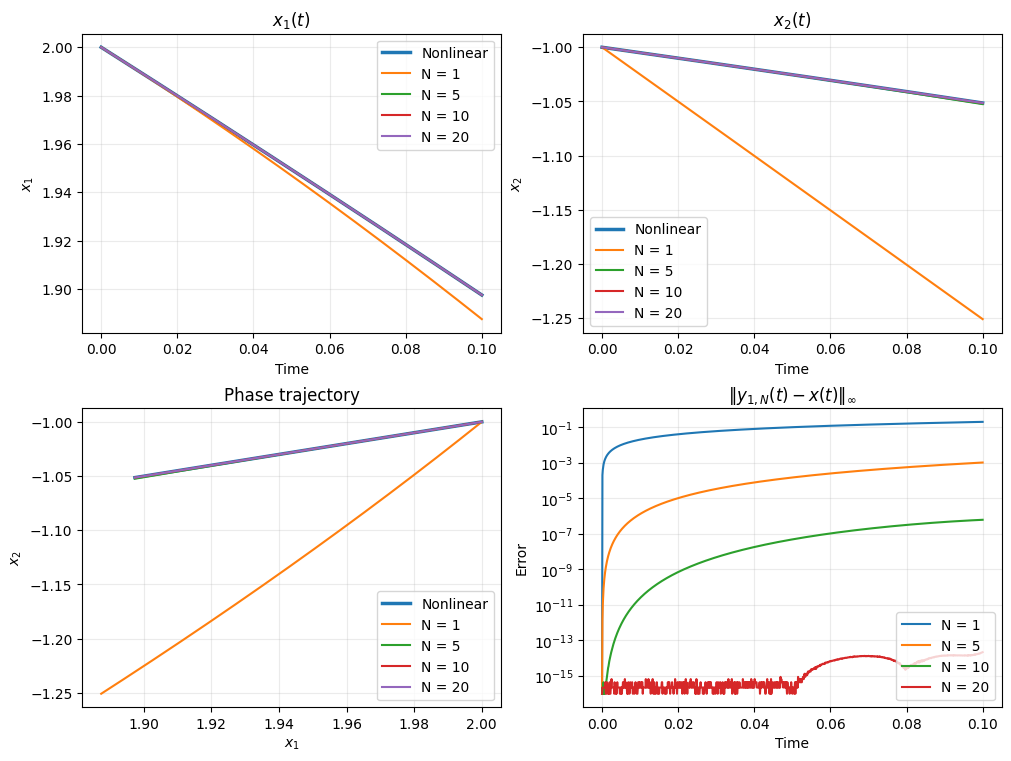

N= 1: maximum error = 1.994161e-01
N= 5: maximum error = 1.026408e-03
N=10: maximum error = 6.147509e-07
N=20: maximum error = 2.176037e-14


In [6]:
figure, axes = plt.subplots(2, 2, figsize=(10.0, 7.5), constrained_layout=True)

axes[0, 0].plot(trajectory_times, trajectory_exact[:, 0], linewidth=2.5, label="Nonlinear")
axes[0, 1].plot(trajectory_times, trajectory_exact[:, 1], linewidth=2.5, label="Nonlinear")
axes[1, 0].plot(trajectory_exact[:, 0], trajectory_exact[:, 1], linewidth=2.5, label="Nonlinear")

for order in trajectory_orders:
    approximation = trajectory_approximations[order]
    axes[0, 0].plot(trajectory_times, approximation[:, 0], label=f"N = {order}")
    axes[0, 1].plot(trajectory_times, approximation[:, 1], label=f"N = {order}")
    axes[1, 0].plot(approximation[:, 0], approximation[:, 1], label=f"N = {order}")
    axes[1, 1].semilogy(
        trajectory_times,
        np.maximum(trajectory_errors[order], 1e-16),
        label=f"N = {order}",
    )

axes[0, 0].set_title(r"$x_1(t)$")
axes[0, 1].set_title(r"$x_2(t)$")
axes[1, 0].set_title("Phase trajectory")
axes[1, 1].set_title(r"$\|y_{1,N}(t)-x(t)\|_\infty$")

axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel(r"$x_1$")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel(r"$x_2$")
axes[1, 0].set_xlabel(r"$x_1$")
axes[1, 0].set_ylabel(r"$x_2$")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel("Error")

for axis in axes.ravel():
    axis.grid(True, alpha=0.25)
    axis.legend()

plt.show()

for order in trajectory_orders:
    print(f"N={order:2d}: maximum error = {trajectory_errors[order].max():.6e}")

### Vector field and limit cycle

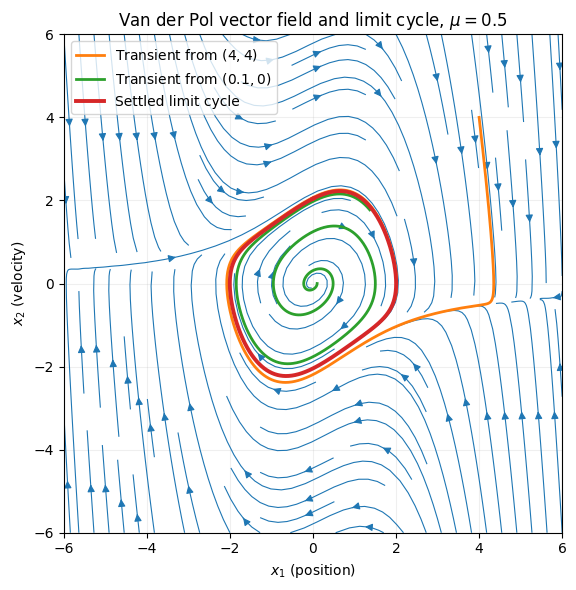

Estimated limit-cycle period: 6.380675802
Maximum |x1| on the cycle:    2.002486922
Maximum |x2| on the cycle:    2.226975377


In [7]:
plt.figure(figsize=(7.2, 6.0))
plt.streamplot(
    X1,
    X2,
    U,
    V,
    density=1.15,
    linewidth=0.8,
    arrowsize=1.1,
)
plt.plot(
    outer_trajectory[:, 0],
    outer_trajectory[:, 1],
    linewidth=2.0,
    label=r"Transient from $(4,4)$",
)
plt.plot(
    inner_trajectory[:, 0],
    inner_trajectory[:, 1],
    linewidth=2.0,
    label=r"Transient from $(0.1,0)$",
)
plt.plot(cycle[:, 0], cycle[:, 1], linewidth=2.8, label="Settled limit cycle")
plt.xlim(-6.0, 6.0)
plt.ylim(-6.0, 6.0)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel(r"$x_1$ (position)")
plt.ylabel(r"$x_2$ (velocity)")
plt.title(r"Van der Pol vector field and limit cycle, $\mu=0.5$")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Estimated limit-cycle period: {cycle_period:.9f}")
print(f"Maximum |x1| on the cycle:    {np.max(np.abs(cycle[:, 0])):.9f}")
print(f"Maximum |x2| on the cycle:    {np.max(np.abs(cycle[:, 1])):.9f}")

### Figure 4.3

Lifted dimensions
  N= 1: 2 states
  N=10: 65 states
  N=20: 230 states
N= 1: maximum grid error = 5.436882e+00
      origin error       = 0.000000e+00
N=10: maximum grid error = 2.448483e+00
      origin error       = 0.000000e+00
N=20: maximum grid error = 1.657297e-01
      origin error       = 0.000000e+00


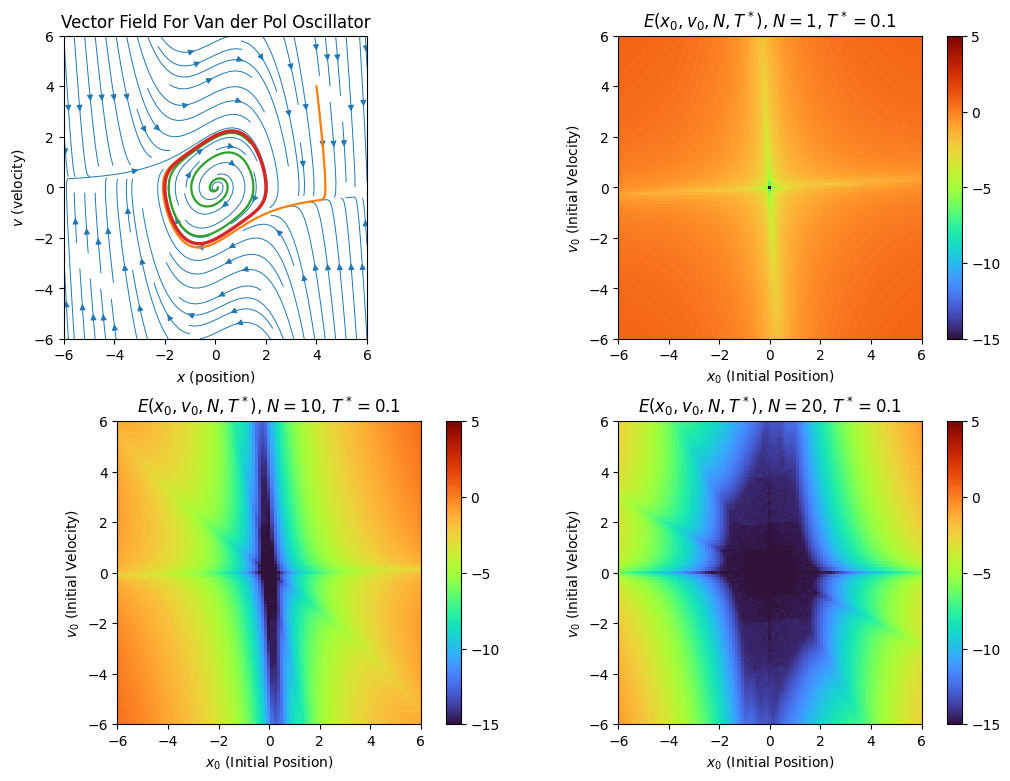

In [8]:
figure, axes = plt.subplots(2, 2, figsize=(10.0, 7.7), constrained_layout=True)

axes[0, 0].streamplot(
    X1,
    X2,
    U,
    V,
    density=1.0,
    linewidth=0.7,
    arrowsize=0.9,
)
axes[0, 0].plot(outer_trajectory[:, 0], outer_trajectory[:, 1], linewidth=1.6)
axes[0, 0].plot(inner_trajectory[:, 0], inner_trajectory[:, 1], linewidth=1.6)
axes[0, 0].plot(cycle[:, 0], cycle[:, 1], linewidth=2.4)
axes[0, 0].set_xlim(-6.0, 6.0)
axes[0, 0].set_ylim(-6.0, 6.0)
axes[0, 0].set_aspect("equal", adjustable="box")
axes[0, 0].set_xlabel(r"$x$ (position)")
axes[0, 0].set_ylabel(r"$v$ (velocity)")
axes[0, 0].set_title("Vector Field For Van der Pol Oscillator")

for axis, order in zip([axes[0, 1], axes[1, 0], axes[1, 1]], map_orders):
    display = np.log10(np.clip(error_maps[order], 1e-15, 1e5))
    image = axis.imshow(
        display,
        origin="lower",
        extent=[grid[0], grid[-1], grid[0], grid[-1]],
        aspect="equal",
        cmap="turbo",
        vmin=-15,
        vmax=5,
    )
    axis.set_xlabel(r"$x_0$ (Initial Position)")
    axis.set_ylabel(r"$v_0$ (Initial Velocity)")
    axis.set_title(rf"$E(x_0,v_0,N,T^*)$, $N={order}$, $T^*=0.1$")
    figure.colorbar(image, ax=axis, ticks=[-15, -10, -5, 0, 5])


print("Lifted dimensions")
for order in map_orders:
    print(f"  N={order:2d}: {matrices[order].shape[0]} states")

origin_index = np.argmin(np.abs(grid))
for order in map_orders:
    print(f"N={order:2d}: maximum grid error = {error_maps[order].max():.6e}")
    print(f"      origin error       = {error_maps[order][origin_index, origin_index]:.6e}")